EDA_checklist
       - Navadeep

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


Task 1 — Inspect & Handle Missing Values

In [11]:
print(df.shape)
print( )
print(df.dtypes)
print( )
null=df.isnull().sum()
print( )
print(f"Total missing values\n{null}")
print( )
print(null/len(df) * 100)

(200, 6)

order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object


Total missing values
order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


Task 2 — Summarize & Visualize

In [13]:
print(df.describe)

<bound method NDFrame.describe of      order_id       city     category  order_value  delivery_days rating
0        1001  Bangalore    Groceries       4191.0           11.0      4
1        1002    Chennai    Furniture       4923.0           12.0      1
2        1003     Mumbai    Groceries       4882.0           13.0      2
3        1004  Bangalore  Electronics       1848.0           13.0      1
4        1005  Bangalore    Furniture       1645.0           12.0      1
..        ...        ...          ...          ...            ...    ...
195      1196      Delhi    Furniture       1768.0           12.0      5
196      1197      Delhi    Furniture       4200.0            5.0      1
197      1198    Chennai     Clothing       2938.0            4.0      4
198      1199     Mumbai    Furniture       3698.0            3.0      2
199      1200  Bangalore  Electronics       4113.0            3.0   None

[200 rows x 6 columns]>


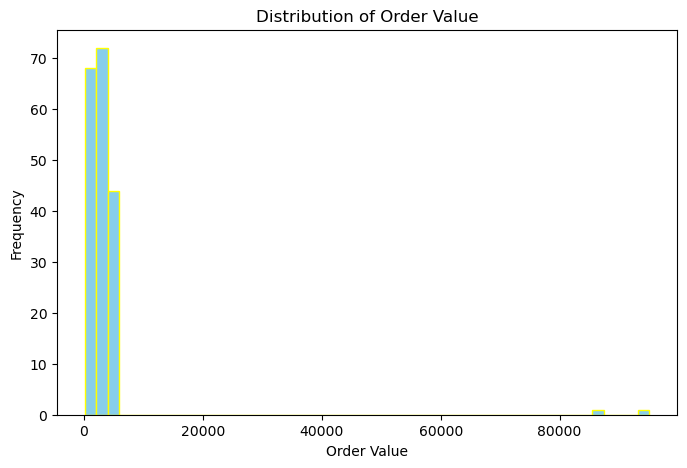

In [22]:
import matplotlib.pyplot as plt

# Plotting the histogram for order_value
plt.figure(figsize=(8,5))
plt.hist(df['order_value'].dropna(), bins=50, color='skyblue', edgecolor='yellow')

# Adding titles and labels
plt.title('Distribution of Order Value')
plt.xlabel('Order Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()

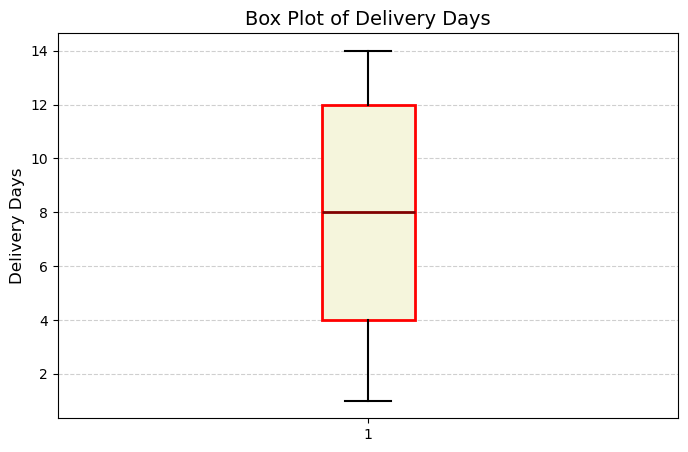

In [36]:
#boxplot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(
    df["delivery_days"].dropna(),
    patch_artist=True,   # enables color fill
    boxprops=dict(facecolor="beige", color="red", linewidth=2),
    whiskerprops=dict(color="black", linewidth=1.5),
    capprops=dict(color="black", linewidth=1.5),
    medianprops=dict(color="maroon", linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='orange', markersize=8)
)

plt.title("Box Plot of Delivery Days", fontsize=14)
plt.ylabel("Delivery Days", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

Task 3 — Correlation Analysis

In [42]:
coll= df.corr(numeric_only="True")
print(coll)

               order_id  order_value  delivery_days
order_id       1.000000    -0.095503       0.004858
order_value   -0.095503     1.000000       0.141660
delivery_days  0.004858     0.141660       1.000000


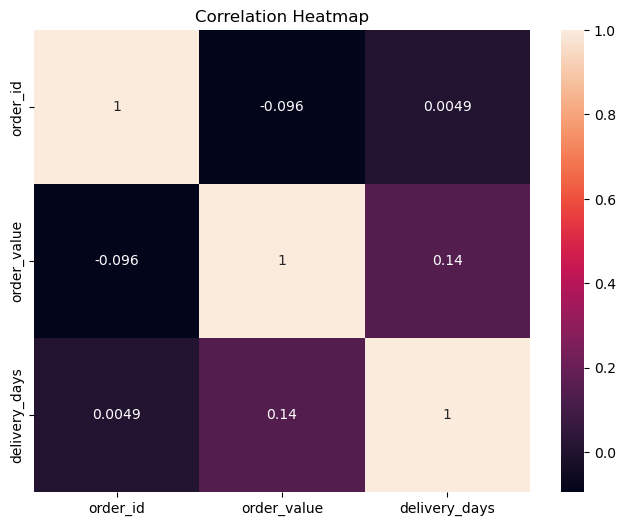

In [45]:
#HEAT MAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(coll, annot=True)
plt.title("Correlation Heatmap")
plt.show()